**Python code of Rossler attractor, base paper "WyNDA"**

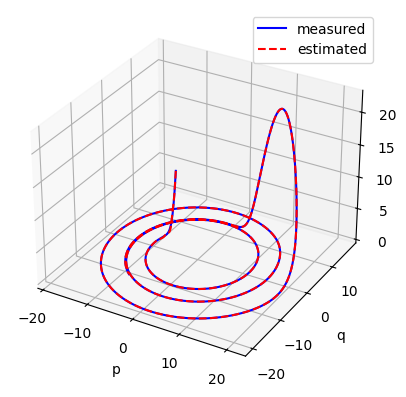

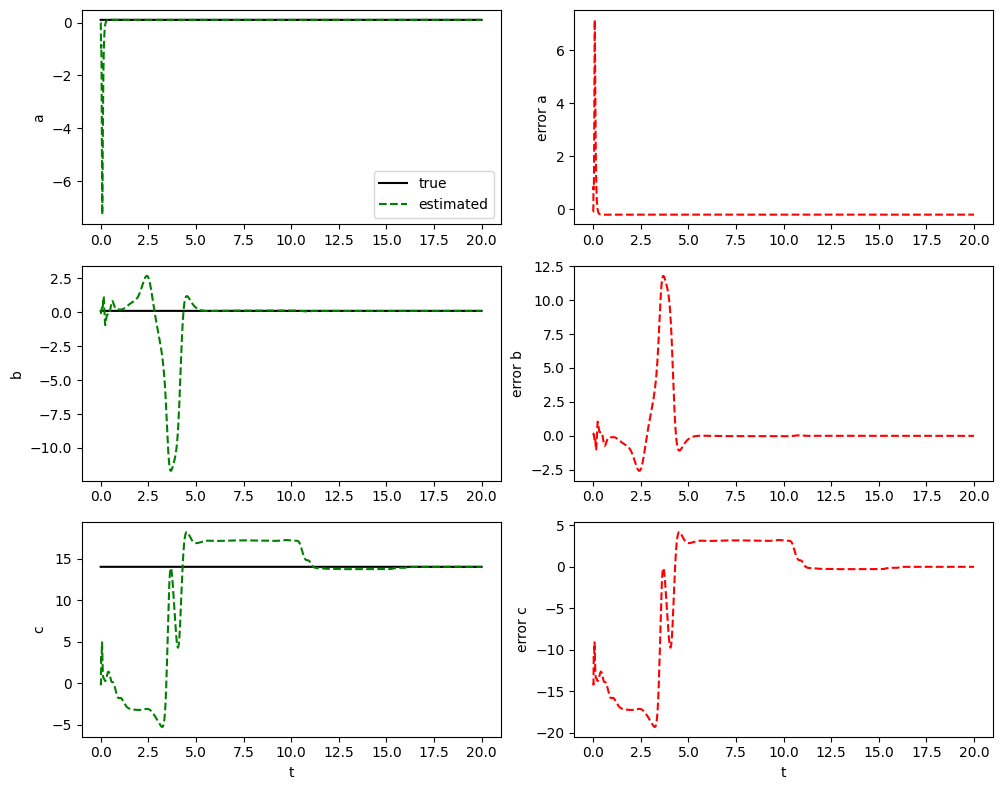

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# defining time horizon
tf = 20
dt = 0.001
t = np.arange(dt, tf + dt, dt)

# defining system dimensions
n = 3
r = 16

# noise into the systems
R = 0

# state initialization
x = np.array([-8.0, 5.0, 10.0])
xbar = x.copy()
y = x.copy()
thetabar = np.zeros(r)

# true parameters
a = 0.1
b = 0.1
c = 14


# storage arrays for storing
xArray = []
xbarArray = []
yArray = []
thetabarArray = []

# estimator initialization
lambdav = 0.995
lambdat = 0.999

Rx = np.eye(n)
Rt = np.eye(n)

Px = 0.1 * np.eye(n)
Pt = 0.1 * np.eye(r)

Gamma = np.zeros((n, r))

# simulation
for i in range(int(tf/dt)):

    xArray.append(x.copy())
    xbarArray.append(xbar.copy())
    yArray.append(y.copy())
    thetabarArray.append(thetabar.copy())

    # Rossler dynamics
    dx = np.array([
        -x[1] - x[2],
        x[0] + a*x[1],
        b + x[2]*(x[0] - c)
    ])

    x = x + dt * dx
    y = x + dt*(R**2)*np.random.randn(n)

    # library matrix phi
    Phi = np.zeros((3,16))

    Phi[0,0:3] = [y[0], y[1], y[2]]

    Phi[1,3:6] = [y[0], y[1], y[2]]

    Phi[2,6:16] = [
        1,
        y[0], y[1], y[2],
        y[0]**2, y[1]**2, y[2]**2,
        y[0]*y[1], y[0]*y[2], y[1]*y[2]
    ]

    # adaptive observer
    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)

    Gamma = (np.eye(n) - Kx) @ Gamma

    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)

    xbar = xbar + Phi @ thetabar

    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt

    Gamma = Gamma - Phi


# converting arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
yArray = np.array(yArray).T
thetabarArray = np.array(thetabarArray).T

# plotting 3D attractor
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(yArray[0], yArray[1], yArray[2], 'b')
ax.plot(xbarArray[0], xbarArray[1], xbarArray[2], 'r--')

ax.set_xlabel("p")
ax.set_ylabel("q")
ax.set_zlabel("r")
ax.legend(["measured","estimated"])

plt.show()

# plotting paramter estimation graphs
fig, axs = plt.subplots(3,2, figsize=(10,8))

# a
axs[0,0].plot(t, a*np.ones_like(t),'k')
axs[0,0].plot(t, thetabarArray[4]/dt,'g--')
axs[0,0].set_ylabel("a")
axs[0,0].legend(["true","estimated"])

axs[0,1].plot(t, -a - thetabarArray[4]/dt,'r--')
axs[0,1].set_ylabel("error a")

# b
axs[1,0].plot(t, b*np.ones_like(t),'k')
axs[1,0].plot(t, thetabarArray[6]/dt,'g--')
axs[1,0].set_ylabel("b")

axs[1,1].plot(t, b - thetabarArray[6]/dt,'r--')
axs[1,1].set_ylabel("error b")

# c
axs[2,0].plot(t, c*np.ones_like(t),'k')
axs[2,0].plot(t, -thetabarArray[9]/dt,'g--')
axs[2,0].set_ylabel("c")
axs[2,0].set_xlabel("t")

axs[2,1].plot(t, -c - thetabarArray[9]/dt,'r--')
axs[2,1].set_ylabel("error c")
axs[2,1].set_xlabel("t")

plt.tight_layout()
plt.show()
